In [2]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy.stats import t as tdist
from sklearn.ensemble import  GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict




[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Loading

In [ ]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.head()

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
aroma_df= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_df.csv')

aroma_df.head()

,Variety,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
0,ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,22.334351,0.0,18.799602,0.000000
1,AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,0.000000,0.0,15.924101,18.039118
2,ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,0.000000,0.0,19.520823,0.000000
3,ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,18.548808,0.0,0.000000,20.209723
4,ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,0.000000,0.0,0.000000,0.000000


In [13]:
sensory_pcs = pd.read_csv("sensory_pca_scores.csv")
print(sensory_pcs.head())

     Variety        PC1       PC2       PC3
0      ADORA  14.107594 -2.357611  2.590603
1      AGRIA  -0.426622  0.649625 -4.645229
2     BERBER  -1.598219 -1.697338  1.620715
3  BILDTSTAR   0.031193  1.147409 -4.379258
4     BINTJE  -5.148293 -0.944492 -1.292184


In [14]:
print(genetic_data.shape)
print(aroma_df.shape)
print(sensory_pcs.shape)

(262434, 95)
(94, 14)
(94, 4)


# Data preparation

The genetic marker and aroma datasets were cleaned by removing missing values, duplicates, and constant features. Variety names were standardized and replicates collapsed by averaging. A curated list of aroma compounds was retained, and all values were converted to numeric format. The cleaned genetic and aroma tables were merged by variety, while the flavor dataset was kept separate for later analysis.

In [ ]:
# Preparing the data 

def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]

# Detecting the SNP marker column
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

# Clean genetics 
G = genetic_data.dropna(subset=[mrk_col]) \
                .drop_duplicates(subset=[mrk_col]) \
                .set_index(mrk_col)

G = to_numeric(G)
gd = G.T                         
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates if multiple rows per variety
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

#  Aroma 
af = aroma_df.copy()
assert "Variety" in af.columns, "aroma_df must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

# aroma names 
aroma_names = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

col_str = af.columns.astype(str)


# Keep only aroma compounds of interest that exist in dataset
aroma_cols = [c for c in aroma_names if c in col_str]

A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
 # drop constant cols
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]  



print(f"# aroma candidates (usable): {A.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

#  Merge genetics with aroma
gk = gd.copy()
gk.index.name = "Variety"

merged_snp_aroma = gk.join(A, how="inner")
print("Merged shape (varieties × [SNPs + aroma]):",merged_snp_aroma.shape)

#  Sensory PCs 
sensory_pcs = pd.read_csv("sensory_pca_scores.csv")
assert "Variety" in sensory_pcs.columns, "sensory_pca_scores.csv must have a 'Variety' column"

# Normalize variety names
sensory_pcs["__key__"] = sensory_pcs["Variety"].map(norm_key)
sensory_pcs = sensory_pcs.set_index("__key__")

# Convert to numeric (drop text columns if any remain)
S = to_numeric(sensory_pcs.drop(columns=["Variety"], errors="ignore"))

print(f"# sensory PCs: {S.shape[1]}")
print("Sample sensory cols:", list(S.columns[:8]))

# Merge genetics with sensory 
merged_snp_sensory = gk.join(S, how="inner")
print("Merged shape (varieties × [SNPs + sensory PCs]):", merged_snp_sensory.shape)

#  Merge genetics + aroma + sensory
merged_all = gk.join(pd.concat([A, S], axis=1), how="inner")
print("Merged shape (varieties × [SNPs + aroma + sensory PCs]):", merged_all.shape)


Genetic table after reshape: (94, 262434)
# aroma candidates (usable): 13
Sample aroma cols: ['1-Nonanol (Floral, waxy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)']
Merged shape (varieties × [SNPs + aroma]): (94, 262447)
# sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']
Merged shape (varieties × [SNPs + sensory PCs]): (94, 262437)
Merged shape (varieties × [SNPs + aroma + sensory PCs]): (94, 262450)


# Exploratory analysis:

# 1.HCA (Ward, Euclidean) on SNP-linked aroma profiles (EDA)

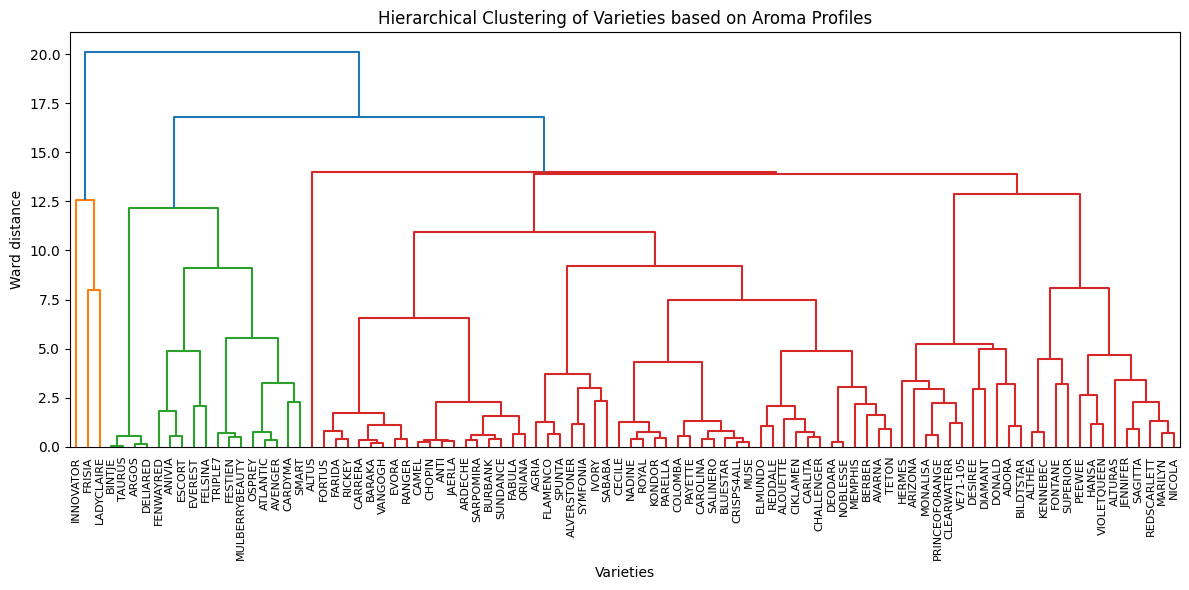

In [19]:

merged_snp_aroma= merged_snp_aroma.copy()

# use the same aroma list
AROMA_COLS = [c for c in aroma_names if c in merged_snp_aroma.columns]

X = merged_snp_aroma[AROMA_COLS].copy().fillna(0.0)

# scale columns so compounds contribute equally
Xz = pd.DataFrame(StandardScaler().fit_transform(X.values),
                  index=X.index, columns=AROMA_COLS)

Z = linkage(Xz, method="ward", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Varieties based on Aroma Profiles")
plt.xlabel("Varieties"); plt.ylabel("Ward distance")
plt.tight_layout(); plt.show()


Most varieties clustered into two major groups with several smaller subgroups, while a few varieties ( Innovator, Frisia, Lady Claire) appeared as outliers

#Select Kbestt using silhouette score

In [24]:

# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")
for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette 
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")
merged_snp_aroma[f"AromaCluster_k{best_k}"] = clusters
print("\nCluster sizes:\n", pd.Series(clusters, index=merged_snp_aroma.index).value_counts().sort_index())


k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.280   |            3.8     |      1.347
 3 |      0.167   |            3.4     |      2.756
 4 |      0.154   |            3.2     |      2.111
 5 |      0.155   |            3.0     |      1.827
 6 |      0.157   |            2.9     |      1.638
 7 |      0.157   |            2.8     |      1.505
 8 |      0.103   |            2.7     |      1.515
 9 |      0.105   |            2.7     |      1.425
10 |      0.088   |            2.6     |      1.609

Selected k = 2 (by silhouette)

Cluster sizes:
 1     2
2    92
Name: count, dtype: int64


# HCA on merged_snp_sensory 

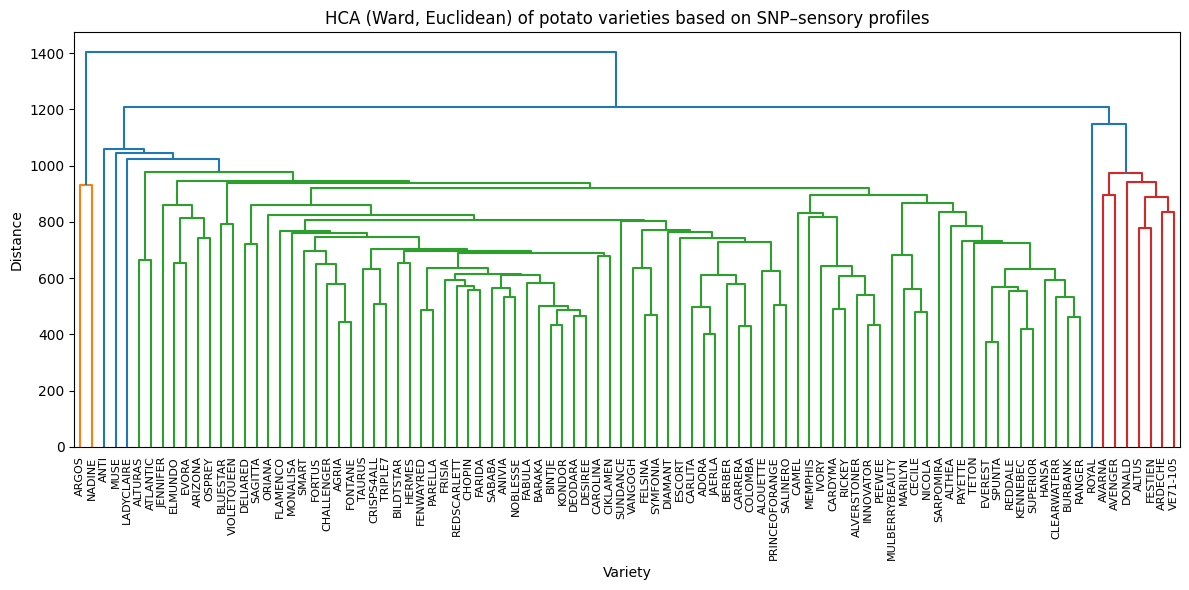

In [ ]:

# Drop non-numeric and missing columns
X = merged_snp_sensory.select_dtypes(include=[np.number]).dropna(axis=1, how="any")

# Drop rows with NaN after selection
X = X.dropna(axis=0, how="any")

# Standardize
Xz = (X - X.mean()) / X.std(ddof=0)

# Replace any inf/-inf created during scaling with NaN, then drop
Xz = Xz.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")

# Compute distance + linkage
D = pdist(Xz, metric="euclidean")
Z = linkage(D, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=Xz.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.7*max(Z[:,2]))
plt.title("HCA (Ward, Euclidean) of potato varieties based on SNP–sensory profiles")
plt.xlabel("Variety")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


Hierarchical clustering of the SNP–sensory dataset grouped the potato varieties into several distinct clusters. Two larger clusters were observed alongside smaller subgroups, with a few varieties separating as clear outliers(Nadin, Argos). This indicates that genetic variation partly explains sensory differences, and some varieties have unique sensory-linked SNP profiles.

In [ ]:

# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")
for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette 
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")
merged_snp_sensory[f"AromaCluster_k{best_k}"] = clusters
print("\nCluster sizes:\n", pd.Series(clusters, index=merged_snp_sensory.index).value_counts().sort_index())


# Predicting flavor/aroma from genome data

Breif about what I did 

# Data Cleaning & Preprocessing